# 2. Fitting exerimental data to constitutive models

In this notebook, we use ForceIndent-JAX to to fit data from force-indentation experiments to various viscoelastic constitutive models. 

In [1]:
%run _common.ipynb
%matplotlib inline
from pathlib import Path
from typing import Callable

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from jaxtyping import Array, Float
from tqdm import tqdm

from neuralconstitutive.constitutive import (
    AbstractConstitutive,
    GeneralizedMaxwellmodel,
    KelvinVoigt,
    KohlrauschWilliamsWatts,
    ModifiedPowerLaw,
    PowerLaw,
    StandardLinearSolid,
)
from neuralconstitutive.dataset import import_data, normalize_dataset, truncate_adhesion
from neuralconstitutive.fitting import (
    bayesian_information_criterion,
    least_squares,
    make_transformation_function,
    sample_params_lhs,
    LeastSquaresResult
)
from neuralconstitutive.indentation import ConstantVelocity, IndentationBuilder
from neuralconstitutive.plotting import MM, plot_eigval_spectrum
from neuralconstitutive.ting.analytic import force_kelvinvoigt, force_powerlaw
from neuralconstitutive.ting.numerical import force_approach, force_retract, force_ting
from neuralconstitutive.tipgeometry import Spherical
from neuralconstitutive.utils.io import load_object, save_object
from neuralconstitutive.utils.pytree import (
    batched_pytree_to_list,
    list_to_batched_pytree,
)

## Import and preprocess experimental data

In [2]:
speed = 5
file_index = 0

# Import data
datadir = Path(f"../data/abuhattum_iscience_2022/PAAM hydrogel/speed {speed}")
name_suffix = "" if file_index == 0 else f"_{file_index}"
filename = f"PAA_speed {speed}_4nN{name_suffix}"

# Preprocessing
dataset = import_data(datadir / f"{filename}.tab", datadir / f"{filename}.tsv")
dataset = truncate_adhesion(dataset)
dataset, scale = normalize_dataset(dataset)

# Define tip geometry in terms of normalized units
tip = Spherical(1e-6 / scale.depth)

# Construct continuous indentation from discrete dataset
indentation = IndentationBuilder(enforce_continuity=False).build_from_dataset(
    dataset, smoothing=1e-3
)

## Fit analytical solutions to data

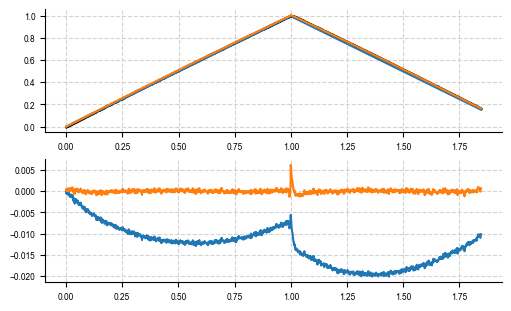

In [3]:
def get_slope(t: Float[Array, " N"], x: Float[Array, " N"]):
    return (x[-1] - x[0]) / (t[-1] - t[0])


v_approx = 0.5 * (
    get_slope(dataset.approach.time, dataset.approach.depth)
    - get_slope(dataset.retract.time, dataset.retract.depth)
)

indentation_linear = (
    IndentationBuilder(enforce_continuity=True)
    .append(ConstantVelocity(v_approx), duration=dataset.approach.time[-1])
    .append(
        ConstantVelocity(-v_approx),
        duration=dataset.retract.time[-1] - dataset.approach.time[-1],
    )
    .build()
)

fig, axes = plt.subplots(2, 1, figsize=(5, 3))
axes[0].plot(dataset.total_time, dataset.total_depth, ".", color="k")
axes[0].plot(
    dataset.total_time,
    indentation_linear.depth(dataset.total_time),
    label="Constant velocity",
)
axes[0].plot(
    dataset.total_time, indentation.depth(dataset.total_time), label="Cubic spline"
)

axes[1].plot(
    dataset.total_time[1:],
    (
        indentation_linear.depth(dataset.total_time)
        - dataset.total_depth
        # / dataset.total_depth
    )[1:],
    label="Constant velocity",
)
axes[1].plot(
    dataset.total_time[1:],
    (
        indentation.depth(dataset.total_time)
        - dataset.total_depth
        # / dataset.total_depth
    )[1:],
    label="Cubic spline",
)

In [4]:
def make_residual_pl(approach_only: bool = False):
    @eqx.filter_jit
    def _residual_app(constit, args):
        indentation, tip, dataset = args
        f_app_pred = force_powerlaw(dataset.t_app, constit, indentation, tip)
        return f_app_pred - dataset.f_app

    @eqx.filter_jit
    def _residual(constit, args):
        indentation, tip, dataset = args
        force_pred = force_powerlaw(dataset.total_time, constit, indentation, tip)
        return force_pred - dataset.total_force

    return _residual_app if approach_only else _residual


def make_residual_kv(approach_only: bool = False):
    @eqx.filter_jit
    def _residual_app(constit, args):
        indentation, tip, dataset = args
        f_app_pred = force_kelvinvoigt(dataset.t_app, constit, indentation, tip)
        return f_app_pred - dataset.f_app

    @eqx.filter_jit
    def _residual(constit, args):
        indentation, tip, dataset = args
        force_pred = force_kelvinvoigt(dataset.total_time, constit, indentation, tip)
        return force_pred - dataset.total_force

    return _residual_app if approach_only else _residual

In [5]:
args = (indentation_linear, tip, dataset)
residual_func = make_residual_kv(approach_only=True)
sols = []
bounds = (
    KelvinVoigt(0.0, 0.0),
    KelvinVoigt(jnp.inf, jnp.inf),
)

samples = sample_params_lhs(25, ([1e-3, 1e-3], [1e2, 1e2]), scale=["log", "log"])

batch_size = 25
n_batches = len(samples) // batch_size
sols_batch = []


def helper(y0):
    return least_squares(residual_func, y0, args, bounds, throw=False, max_iter=128)

In [6]:
for i in tqdm(range(n_batches)):
    samples_batch = jnp.stack(samples[i : i + batch_size], axis=-1)
    y0_batch = eqx.filter_vmap(KelvinVoigt)(*samples_batch)
    sol_batch = eqx.filter_vmap(helper)(y0_batch)
    sols_batch.append(sol_batch)

  0%|          | 0/1 [00:00<?, ?it/s]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
100%|██████████| 1/1 [00:05<00:00,  5.21s/it]


In [7]:
sols_kv = list_to_batched_pytree(sols_batch)
save_object(sols_kv, "../outputs/kelvin_voigt_analytic_approach.pkl")

In [8]:
args = (indentation_linear, tip, dataset)
residual_func = make_residual_pl(approach_only=True)
sols = []
bounds = (
    PowerLaw(0.0, 0.0),
    PowerLaw(jnp.inf, 1.0),
)

samples = sample_params_lhs(25, ([1e-3, 0.0], [1e2, 1.0]), scale=["log", "linear"])

batch_size = 25
n_batches = len(samples) // batch_size
sols_batch = []


def helper(y0):
    return least_squares(residual_func, y0, args, bounds, throw=False, max_iter=128)

In [9]:
for i in tqdm(range(n_batches)):
    samples_batch = jnp.stack(samples[i : i + batch_size], axis=-1)
    y0_batch = eqx.filter_vmap(PowerLaw)(*samples_batch)
    sol_batch = eqx.filter_vmap(helper)(y0_batch)
    sols_batch.append(sol_batch)

  0%|          | 0/1 [00:00<?, ?it/s]2024-09-09 15:09:42.027022: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
100%|██████████| 1/1 [00:40<00:00, 40.71s/it]


In [10]:
sols_pl = list_to_batched_pytree(sols_batch)
save_object(sols_pl, "../outputs/power_law_analytic_approach.pkl")

In [15]:
def make_residual(approach_only: bool = False):
    @eqx.filter_jit
    def _residual_app(constit, args):
        indentation, tip, dataset = args
        f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
        return f_app_pred - dataset.f_app

    @eqx.filter_jit
    def _residual(constit, args):
        indentation, tip, dataset = args
        f_app, f_ret = dataset.f_app, dataset.f_ret
        f_app_pred = force_approach(dataset.t_app, constit, indentation, tip)
        f_ret_pred = force_retract(dataset.t_ret, constit, indentation, tip)
        return jnp.concatenate((f_app_pred - f_app, f_ret_pred - f_ret))

    return _residual_app if approach_only else _residual


residual_func = make_residual()

In [12]:
residual_func = make_residual(approach_only=True)
sols = []
bounds = (
    ModifiedPowerLaw(0.0, 0.0, 0.0),
    ModifiedPowerLaw(jnp.inf, 1.0, jnp.inf),
)

samples = sample_params_lhs(
    125, ([1e-3, 0.0, 1e-3], [1e2, 1.0, 1e2]), scale=["log", "linear", "log"]
)

batch_size = 25
n_batches = len(samples) // batch_size
sols_batch = []

args = (indentation, tip, dataset)


def helper(y0):
    return least_squares(residual_func, y0, args, bounds, throw=False, max_iter=128)

In [13]:
for i in tqdm(range(n_batches)):
    samples_batch = jnp.stack(samples[i : i + batch_size], axis=-1)
    y0_batch = eqx.filter_vmap(ModifiedPowerLaw)(*samples_batch)
    sol_batch = eqx.filter_vmap(helper)(y0_batch)
    sols_batch.append(sol_batch)

  0%|          | 0/5 [00:00<?, ?it/s]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 20%|██        | 1/5 [00:42<02:48, 42.00s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 40%|████      | 2/5 [01:23<02:04, 41.42s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 60%|██████    | 3/5 [02:02<01:21, 4

In [14]:
sols_final = list_to_batched_pytree(sols_batch)
save_object(sols_final, "../outputs/modified_power_law_approach.pkl")

In [15]:
residual_func = make_residual(approach_only=True)
sols = []
bounds = (
    StandardLinearSolid(0.0, 0.0, 0.0),
    StandardLinearSolid(jnp.inf, jnp.inf, jnp.inf),
)

samples = sample_params_lhs(
    125, ([1e-3, 1e-3, 1e-3], [1e2, 1e2, 1e2]), scale=["log", "log", "log"]
)

batch_size = 25
n_batches = len(samples) // batch_size
sols_batch = []

args = (indentation, tip, dataset)


def helper(y0):
    return least_squares(residual_func, y0, args, bounds, throw=False, max_iter=128)

In [16]:
for i in tqdm(range(n_batches)):
    samples_batch = jnp.stack(samples[i : i + batch_size], axis=-1)
    y0_batch = eqx.filter_vmap(StandardLinearSolid)(*samples_batch)
    sol_batch = eqx.filter_vmap(helper)(y0_batch)
    sols_batch.append(sol_batch)

  0%|          | 0/5 [00:00<?, ?it/s]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 20%|██        | 1/5 [00:31<02:07, 31.87s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 40%|████      | 2/5 [01:03<01:34, 31.46s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 60%|██████    | 3/5 [01:33<01:02, 3

In [17]:
save_object(sols_final, "../outputs/standard_linear_solid_approach.pkl")

In [7]:
residual_func = make_residual(approach_only=True)
sols = []
bounds = (
    KohlrauschWilliamsWatts(0.0, 0.0, 0.0, 0.0),
    KohlrauschWilliamsWatts(jnp.inf, jnp.inf, jnp.inf, 1.0),
)

samples = sample_params_lhs(
    5**4,
    ([1e-3, 1e-3, 1e-3, 0.0], [1e2, 1e2, 1e2, 1.0]),
    scale=["log", "log", "log", "linear"],
)

batch_size = 125
n_batches = len(samples) // batch_size
sols_batch = []

args = (indentation, tip, dataset)


def helper(y0):
    return least_squares(residual_func, y0, args, bounds, throw=False, max_iter=128)

In [8]:
for i in tqdm(range(n_batches)):
    samples_batch = jnp.stack(samples[i : i + batch_size], axis=-1)
    y0_batch = eqx.filter_vmap(KohlrauschWilliamsWatts)(*samples_batch)
    sol_batch = eqx.filter_vmap(helper)(y0_batch)
    sols_batch.append(sol_batch)

  0%|          | 0/5 [00:00<?, ?it/s]

/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 20%|██        | 1/5 [03:06<12:27, 186.83s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 40%|████      | 2/5 [06:10<09:15, 185.07s/it]/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(
 60%|██████    | 3/5 [09:15<06:09, 184.85s/it]/home/jhko725/mambaforge/

In [9]:
sol_final = list_to_batched_pytree(sols_batch)
save_object(sol_final, "../outputs/kohlrausch_williams_watts_approach.pkl")

## Import curve fit results and analyze fit results

In [3]:
from pathlib import Path

model_names = ("Modified Power Law", "Standard Linear Solid", "Kohlraus Williams Watts")
savedir = Path("../outputs")


def modelname_to_filename(name: str) -> str:
    return "_".join(name.lower().split(" ")) + ".pkl"


modelname_to_filename(model_names[0])

'modified_power_law.pkl'

In [17]:
result = load_object(savedir / modelname_to_filename(model_names[0]))
result.success

Array([ True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True, False,  True,  True,  True,  True, False,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False,  True,
        True,  True,  True, False,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True, False,  True,  True,  True,  True,
       False,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True, False],      dtype=bool)

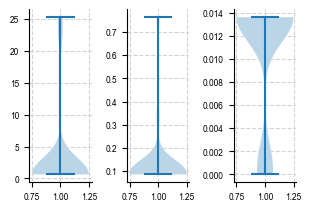

In [21]:
import dataclasses

param_dict = dataclasses.asdict(result.value)

fig, axes = plt.subplots(1, 3, figsize=(3, 2))
for ax, v in zip(axes, param_dict.values()):
    ax.violinplot(v[result.success])
    # ax.set_yscale("log", base = 10)

In [26]:
from neuralconstitutive.fitting import bayesian_information_criterion

residual_func = make_residual(indentation, tip, dataset)
result_list = batched_pytree_to_list(result)
bic_func = eqx.filter_jit(bayesian_information_criterion)
bic = jnp.asarray([bic_func(residual_func, r.value, args) for r in tqdm(result_list)])
bic

  0%|          | 0/125 [00:00<?, ?it/s]

100%|██████████| 125/125 [00:09<00:00, 13.61it/s]


Array([-23640.41598407, -23640.41619949, -23640.41595635, -23640.41614797,
       -13923.02136746, -23640.41617853, -23581.77507588, -19620.58156971,
       -23640.41653515, -23640.41607201, -23640.41596829, -23640.41667315,
       -19331.83451488, -23600.83245567, -23640.41650837, -23640.41587333,
       -15883.50997085, -23640.41650331, -23640.41596388, -23640.41587646,
       -23640.41611796, -23595.13622138, -23640.41581694, -23640.4158995 ,
       -23640.41611188, -23640.41619949, -23640.41595635, -23640.41614797,
       -13923.02136746, -23640.41617853, -23581.77507588, -19620.58156971,
       -23640.41653515, -23640.41607201, -23640.41596829, -23640.41667315,
       -19331.83451488, -23600.83245567, -23640.41650837, -23640.41587333,
       -15883.50997085, -23640.41650331, -23640.41596388, -23640.41587646,
       -23640.41611796, -23595.13622138, -23640.41581694, -23640.4158995 ,
       -23640.41611188, -23640.41624698, -23640.41595635, -23640.41614797,
       -13923.02136746, -

In [40]:
value_best = jax.tree.map(lambda x: x[jnp.argmin(bic)], result.value)
print(dataclasses.asdict(value_best))

{'E0': Array(0.63493247, dtype=float64), 'alpha': Array(0.09290435, dtype=float64), 't0': Array(0.01361487, dtype=float64)}


In [42]:
force_ting = eqx.filter_jit(force_ting)
f_pred = force_ting(dataset.total_time, value_best, indentation, tip)

In [44]:
jnp.max(jnp.abs(f_pred - dataset.total_force))

Array(0.03846641, dtype=float64)

## Define residual function for the least squares curve fit

In [34]:
bounds = (
    StandardLinearSolid(0.0, 0.0, 0.0),
    StandardLinearSolid(jnp.inf, jnp.inf, jnp.inf),
)
y0 = StandardLinearSolid(10.0, 10.0, 10.0)

to_bounded, to_unbounded = make_transformation_function(bounds)

In [117]:
y_unbounded = eqx.filter_jit(to_unbounded)(y0)
print(y_unbounded.E1, y_unbounded.E_inf, y_unbounded.tau)

10.954451150103322 10.954451150103322 10.954451150103322


In [8]:
y_bounded = eqx.filter_jit(to_bounded)(y_unbounded)
print(y_bounded.E1, y_bounded.E_inf, y_bounded.tau)

10.0 10.0 10.0


In [17]:
bounds = (
    GeneralizedMaxwellmodel(0.0, 0.0, 0.0, 0.0, 0.0),
    GeneralizedMaxwellmodel(jnp.inf, jnp.inf, jnp.inf, jnp.inf, jnp.inf),
)
y0 = GeneralizedMaxwellmodel(1.0, 2.0, 3.0, 4.0, 5.0)

to_bounded, to_unbounded = make_transformation_function(bounds)

sol_jaxopt = least_squares(
    residual_func, y0, args, bounds, backend="jaxopt", method="trf"
)

In [18]:
sol_optx = least_squares(
    residual_func, y0, args, bounds, backend="optimistix", method="levenbergmarquardt"
)

/home/jhko725/mambaforge/envs/blackjax/lib/python3.12/site-packages/jax/_src/core.py:691: FutureWarning: unhashable type: <class 'jax._src.interpreters.partial_eval.DynamicJaxprTracer'>. Attempting to hash a tracer will lead to an error in a future JAX release.
  warnings.warn(


{'max_steps': 256, 'num_steps': Array(83, dtype=int64, weak_type=True)}


In [19]:
print(dataclasses.asdict(sol_jaxopt.value))
print(dataclasses.asdict(sol_optx.value))

{'E1': Array(0.12934413, dtype=float64), 'E2': Array(0.32460302, dtype=float64), 'E_inf': Array(0.14085847, dtype=float64), 'tau1': Array(0.15625678, dtype=float64), 'tau2': Array(7.93678342, dtype=float64)}
{'E1': Array(0.12704656, dtype=float64), 'E2': Array(0.18957147, dtype=float64), 'E_inf': Array(0.2785031, dtype=float64), 'tau1': Array(0.15251358, dtype=float64), 'tau2': Array(4.08811025, dtype=float64)}


In [44]:
f_pred = force_ting(dataset.total_time, sol.value, indentation, tip)

## Plot all of the results

In [11]:
from typing import NamedTuple

from neuralconstitutive.custom_types import FloatScalar

fit_stats = dict()
fit_stats_app = dict()


class FitStatistics(NamedTuple):
    value: AbstractConstitutive
    bic: FloatScalar
    pred: Float[Array, " N"]
    residual: Float[Array, " N"]

In [12]:
# Power Law
args = (indentation_linear, tip, dataset)
result = load_object("../outputs/power_law_analytic.pkl")

bics = eqx.filter_vmap(bayesian_information_criterion, in_axes=(None, 0, None))(
    make_residual_pl(), result.value, args
)
ind_best = jnp.argmin(bics)
value_best = jax.tree.map(lambda x: x[jnp.argmin(bics)], result.value)
f_pred_best = force_powerlaw(dataset.total_time, value_best, indentation_linear, tip)

fit_stats["Power Law"] = FitStatistics(
    value_best, bics[ind_best], f_pred_best, f_pred_best - dataset.total_force
)

result = load_object("../outputs/power_law_analytic_approach.pkl")

bics = eqx.filter_vmap(bayesian_information_criterion, in_axes=(None, 0, None))(
    make_residual_pl(approach_only=True), result.value, args
)
ind_best = jnp.argmin(bics)
value_best = jax.tree.map(lambda x: x[jnp.argmin(bics)], result.value)
f_pred_best = force_powerlaw(dataset.total_time, value_best, indentation_linear, tip)

fit_stats_app["Power Law"] = FitStatistics(
    value_best, bics[ind_best], f_pred_best, f_pred_best - dataset.total_force
)

In [13]:
# Kelvin-Voigt
args = (indentation_linear, tip, dataset)
result = load_object("../outputs/kelvin_voigt_analytic.pkl")

bics = eqx.filter_vmap(bayesian_information_criterion, in_axes=(None, 0, None))(
    make_residual_kv(), result.value, args
)
ind_best = jnp.argmin(bics)
value_best = jax.tree.map(lambda x: x[jnp.argmin(bics)], result.value)
f_pred_best = force_kelvinvoigt(dataset.total_time, value_best, indentation_linear, tip)

fit_stats["Kelvin Voigt"] = FitStatistics(
    value_best, bics[ind_best], f_pred_best, f_pred_best - dataset.total_force
)

result = load_object("../outputs/kelvin_voigt_analytic_approach.pkl")

bics = eqx.filter_vmap(bayesian_information_criterion, in_axes=(None, 0, None))(
    make_residual_kv(approach_only=True), result.value, args
)
ind_best = jnp.argmin(bics)
value_best = jax.tree.map(lambda x: x[jnp.argmin(bics)], result.value)
f_pred_best = force_kelvinvoigt(dataset.total_time, value_best, indentation_linear, tip)

fit_stats_app["Kelvin Voigt"] = FitStatistics(
    value_best, bics[ind_best], f_pred_best, f_pred_best - dataset.total_force
)

In [16]:
# Modified Power Law, Standard Linear Solid, Kohlraus Williams Watts
args = (indentation, tip, dataset)
residual_func = make_residual()
bic_func = eqx.filter_jit(
    lambda x: bayesian_information_criterion(residual_func, x, args)
)
force_ting_jit = eqx.filter_jit(force_ting)

for name in (
    "Modified Power Law",
    "Standard Linear Solid",
    "Kohlrausch Williams Watts",
):
    filepath = f"../outputs/{"_".join(name.lower().split(" "))}.pkl"
    result = load_object(filepath)

    bics = jnp.asarray(
        [bic_func(r) for r in tqdm(batched_pytree_to_list(result.value))]
    )
    ind_best = jnp.argmin(bics)
    value_best = jax.tree.map(lambda x: x[jnp.argmin(bics)], result.value)
    f_pred_best = force_ting_jit(dataset.total_time, value_best, indentation, tip)

    fit_stats[name] = FitStatistics(
        value_best, bics[ind_best], f_pred_best, f_pred_best - dataset.total_force
    )

100%|██████████| 625/625 [00:32<00:00, 19.18it/s]


In [17]:
# Modified Power Law, Standard Linear Solid, Kohlraus Williams Watts
args = (indentation, tip, dataset)
residual_func = make_residual(approach_only=True)
bic_func = eqx.filter_jit(
    lambda x: bayesian_information_criterion(residual_func, x, args)
)
force_ting_jit = eqx.filter_jit(force_ting)

for name in (
    "Modified Power Law",
    "Standard Linear Solid",
    "Kohlrausch Williams Watts",
):
    filepath = f"../outputs/{"_".join(name.lower().split(" "))}_approach.pkl"
    result = load_object(filepath)

    bics = jnp.asarray(
        [bic_func(r) for r in tqdm(batched_pytree_to_list(result.value))]
    )
    ind_best = jnp.argmin(bics)
    value_best = jax.tree.map(lambda x: x[jnp.argmin(bics)], result.value)
    f_pred_best = force_ting_jit(dataset.total_time, value_best, indentation, tip)

    fit_stats_app[name] = FitStatistics(
        value_best, bics[ind_best], f_pred_best, f_pred_best - dataset.total_force
    )

100%|██████████| 625/625 [00:08<00:00, 77.93it/s] 


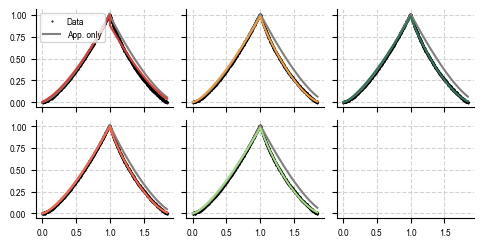

In [27]:
from neuralconstitutive.plotting import cmap_gilpin

fig, axes = plt.subplots(2, 3, figsize=(120 * MM, 60 * MM), sharex=True, sharey=True)
model_names = (
    "Kelvin Voigt",
    "Power Law",
    "Modified Power Law",
    "Standard Linear Solid",
    "Kohlrausch Williams Watts",
)
## Plot curve fitting results for the analytic solutions
for i, (ax, name) in enumerate(zip(axes.flatten(order="F")[0:-1], model_names)):
    ax.plot(
        dataset.total_time,
        dataset.total_force,
        ".",
        color="black",
        label="Data",
        markersize=1.0,
    )
    ax.plot(
        dataset.total_time, fit_stats_app[name].pred, color="gray", label="App. only"
    )
    ax.plot(dataset.total_time, fit_stats[name].pred, color=cmap_gilpin(i))


axes[0, 0].legend(loc="upper left")

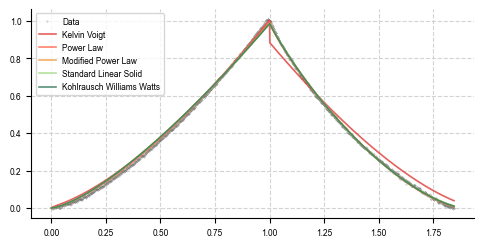

In [87]:
from neuralconstitutive.plotting import cmap_gilpin

fig, ax = plt.subplots(1, 1, figsize=(120 * MM, 60 * MM), sharex=True, sharey=True)
model_names = (
    "Kelvin Voigt",
    "Power Law",
    "Modified Power Law",
    "Standard Linear Solid",
    "Kohlrausch Williams Watts",
)
## Plot curve fitting results for the analytic solutions
ax.plot(
    dataset.total_time,
    dataset.total_force,
    ".",
    color="dimgray",
    label="Data",
    markersize=0.5,
    alpha=0.7,
)

for i, name in enumerate(model_names):
    # ax.plot(
    #    dataset.total_time, fit_stats_app[name].pred, color="gray", label="App. only", alpha = 0.7, linewidth =1.0,
    # )
    ax.plot(
        dataset.total_time,
        fit_stats[name].pred,
        label=name,
        markersize=0.5,
        color=cmap_gilpin(i),
        linewidth=1.2,
        alpha=0.8,
    )


ax.legend(loc="upper left")
fig.savefig("../figures/fig3-a.pdf", format="pdf", dpi=1500)

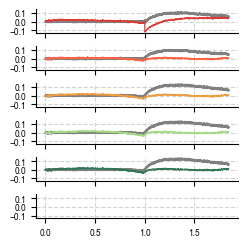

In [30]:
fig, axes = plt.subplots(6, 1, figsize=(60 * MM, 60 * MM), sharex=True, sharey=True)
plot_kwargs = dict(linewidth=0.8)
## Plot curve fitting results for the analytic solutions
for i, (ax, name) in enumerate(zip(axes.flat, model_names)):
    ax.plot(dataset.total_time, fit_stats_app[name].residual, color="gray")
    ax.plot(
        dataset.total_time,
        fit_stats[name].residual,
        color=cmap_gilpin(i),
        **plot_kwargs
    )

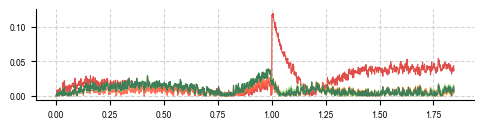

In [86]:
fig, ax = plt.subplots(1, 1, figsize=(120 * MM, 30 * MM), sharex=True, sharey=True)
plot_kwargs = dict(linewidth=0.8, alpha=0.9)
## Plot curve fitting results for the analytic solutions
for i, name in enumerate(model_names):
    # ax.plot(dataset.total_time, fit_stats_app[name].residual, color="gray")
    ax.plot(
        dataset.total_time,
        jnp.abs(fit_stats[name].residual),
        label=name,
        color=cmap_gilpin(i),
        **plot_kwargs
    )
fig.savefig("../figures/fig3-b.pdf", format="pdf", dpi=1200)
# ax.legend()

In [35]:
bic_total

Array([-20976.44608238, -24674.68695378, -23640.41667315, -23622.48489856,
       -23622.39048799], dtype=float64)

<BarContainer object of 5 artists>

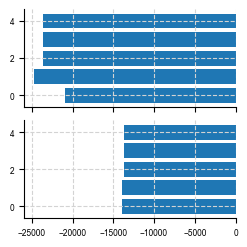

In [36]:
fig, axes = plt.subplots(2, 1, figsize=(60 * MM, 60 * MM), sharex=True)
bic_total = jnp.asarray([fit_stats[n].bic for n in model_names])
bic_app = jnp.asarray([fit_stats_app[n].bic for n in model_names])

axes[0].barh(jnp.arange(len(bic_total)), bic_total)
axes[1].barh(jnp.arange(len(bic_total)), bic_app)

In [53]:
def sensitivity_matrix(constit: AbstractConstitutive, residual_func, args):
    log_constit = jax.tree.map(jnp.log, constit)

    def residual_from_logconstit(log_constit):
        constit = jax.tree.map(jnp.exp, log_constit)
        return residual_func(constit, args)

    D_res = jax.jacfwd(residual_from_logconstit)(log_constit)
    D_res_array, _ = jax.tree.flatten(D_res)
    D_res_array = jnp.stack(D_res_array, axis=-1)

    S = jax.vmap(jnp.outer)(D_res_array, D_res_array)
    return jnp.sum(S, axis=0)

In [54]:
mat = sensitivity_matrix(fit_stats["Modified Power Law"].value, residual_func, args)
mat

Array([[ 359.60485487, -116.54962787,   31.9079612 ],
       [-116.54962787,   42.00986232,  -10.6331228 ],
       [  31.9079612 ,  -10.6331228 ,    2.85295559]], dtype=float64)

In [55]:
eigval, eigvec = jnp.linalg.eigh(mat)
print(eigval, eigvec)

[1.65171712e-03 3.83664902e+00 4.00629372e+02] [[-0.0661098   0.31460698  0.94691707]
 [ 0.06855136  0.94818293 -0.31024158]
 [ 0.99545477 -0.04440244  0.08425092]]


In [56]:
eigval_dict = dict()
eigvec_dict = dict()
for name, fit_stat in tqdm(fit_stats.items()):
    if name == "Power Law":
        args = (indentation_linear, tip, dataset)
        res_func = residual_pl
    elif name == "Kelvin Voigt":
        args = (indentation_linear, tip, dataset)
        res_func = residual_kv
    else:
        args = (indentation, tip, dataset)
        res_func = residual_func

    mat = sensitivity_matrix(fit_stat.value, res_func, args)
    eigval, eigvec = jnp.linalg.eigh(mat)
    eigval_dict[name] = eigval
    eigvec_dict[name] = eigvec

100%|██████████| 5/5 [01:04<00:00, 12.89s/it]


In [57]:
eigval_dict

{'Power Law': Array([  3.90148018, 361.44956402], dtype=float64),
 'Kelvin Voigt': Array([  2.35517504, 346.99840576], dtype=float64),
 'Modified Power Law': Array([1.65171712e-03, 3.83664902e+00, 4.00629372e+02], dtype=float64),
 'Standard Linear Solid': Array([1.70219392e-01, 4.10216297e+00, 3.07126697e+02], dtype=float64),
 'Kohlrausch Williams Watts': Array([1.70219392e-01, 4.10216297e+00, 3.07126697e+02], dtype=float64)}

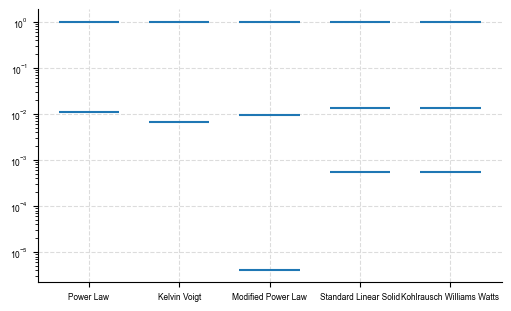

In [64]:
fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax = plot_eigval_spectrum(ax, list(eigval_dict.values()), list(eigval_dict.keys()))
ax.set_yscale("log", base=10)